## Preprocessing

Before running the model, you can either perform preprocessing by yourself or use the preprocessing functions provided in BLEND. Note that both adata and sc_adata should be stored in sparse matrix format.

In [ ]:
import scanpy as sc
import blend
import anndata

adata = sc.read_h5ad('./BLEND_manual/mouse_brain.h5ad')
adata = blend.data_process(adata)
adata = blend.minmax_scale_cells(adata)

Running BLEND_fit initializes the model and returns the necessary components, including the input data, the initialized matrices W, H, V, the single-cell reference matrix, the similarity matrix S, and the rank. The parameter setrank controls the dimension of the low-rank nonnegative matrix factorization. If you do not wish to specify it manually, you can set setrank=0, and the model will automatically estimate the rank. If you do not have single-cell reference data, you can set sc_adata=None.

In [ ]:
data, W_initial, H_initial, sc_reference, V_initial, Similarity_matrix, rank = blend.BLEND_fit(spatial_data=adata, sc_data=None, setrank=20, device="cuda:0")

Iter 0: cost=5037399.500000, improvement=inf
Iter 50: cost=3675629.000000, improvement=1610.000000
Training finished in 25.71 seconds.


## Model

By running the fit function, you obtain the final nonnegative matrix factorization results. The hyperparameters lamb, alpha, and weight can be adjusted by the user. We provide two commonly used parameter combinations:

lamb=10, alpha=13, weight=0.6; lamb=5, alpha=13, weight=0.3

You may also set max_iter to control the maximum number of optimization iterations. For reference, processing data with ~60,000 cells typically takes only a few minutes.

In [ ]:
res = blend.fit(data, W_initial, H_initial, V_initial, Similarity_matrix, P=sc_reference, lamb=10, alpha=13, rank=rank, weight=0.6, max_iter=600, device="cuda:0")
W = res['W']

Iter 0: cost=4782009.000000, improvement=inf
Iter 50: cost=3408495.000000, improvement=1032.000000
Iter 100: cost=3381982.750000, improvement=329.000000
Iter 150: cost=3368524.250000, improvement=237.500000
Iter 200: cost=3357563.250000, improvement=198.000000
Iter 250: cost=3348900.500000, improvement=152.000000
Iter 300: cost=3342206.750000, improvement=118.500000
Iter 350: cost=3336879.750000, improvement=96.250000
Iter 400: cost=3332506.000000, improvement=79.500000
Iter 450: cost=3328816.250000, improvement=68.250000
Iter 500: cost=3325620.500000, improvement=59.750000
Iter 550: cost=3322813.500000, improvement=53.250000


After obtaining the factorization results W (the low-dimensional cell embedding matrix), you can run BLEND’s leiden_cluster function to derive the clustering results and UMAP embeddings from the W matrix.

In [ ]:
cluster, X_umap = blend.blend_leiden_cluster(W, adata,
    resolution = 0.5,
    n_neighbors = 30,
    n_pcs = 30,
    seed = 110,
    log1p = True,
    svd_solver = "arpack",
)

/home/lixuan/program/code_organization/BLEND_main/blend/visualize.py:53: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=resolution, random_state=seed)


In [ ]:
adata.obs['blend'] = cluster
adata.obsm['X_umap'] = X_umap

## Visualization

In [ ]:
custom_colors = ['#3ab5b3','#954f97','#b3d5f1','#f0686c','#5567b1','#80c66d','#8370fe','#1e90ff','#228b22','#ffb90f','#fe0000','#ff7f00','#8b864e','#eaf0b2','#f7d8d6','#c4c2da','#8a8a88','#d8a266','#b86078','#39b086',"#3467a1","#345201","#ebe5c2", "#D57358", "#023047", "#F7CA71", "#1697a6", "#8bc6cc", "#C9DEC3","#169820","#161898"]     

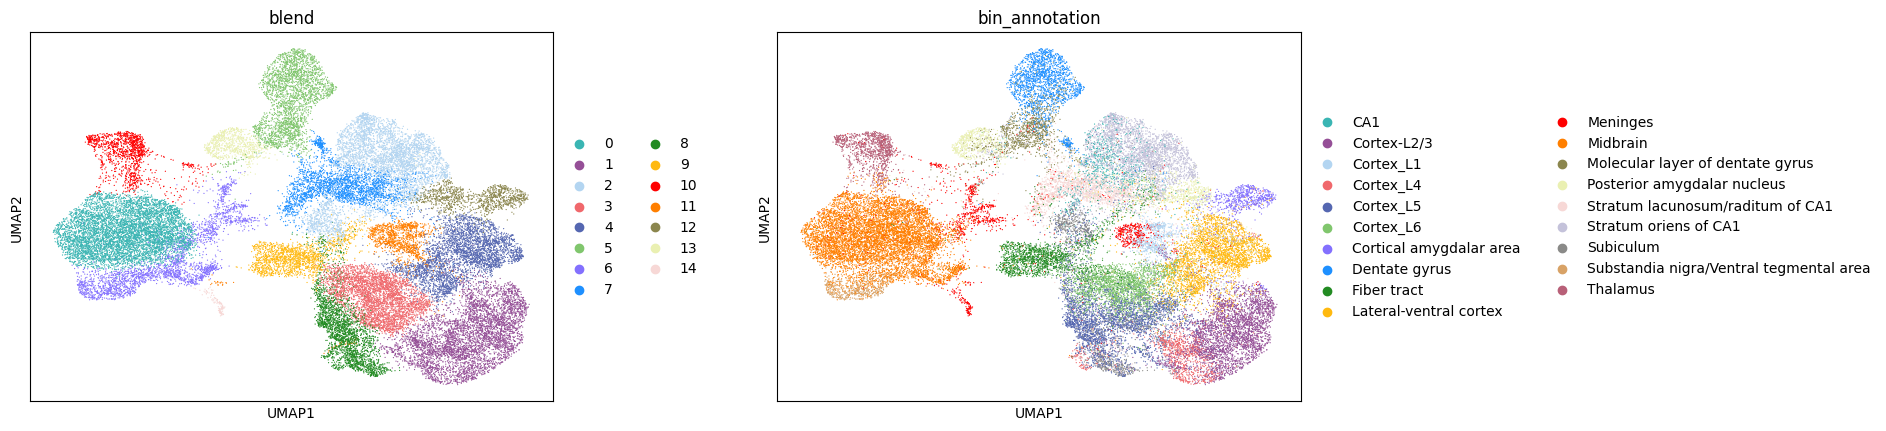

In [ ]:
sc.pl.umap(adata, color=['blend','bin_annotation'], palette=custom_colors, legend_loc='right margin', wspace = 0.3)

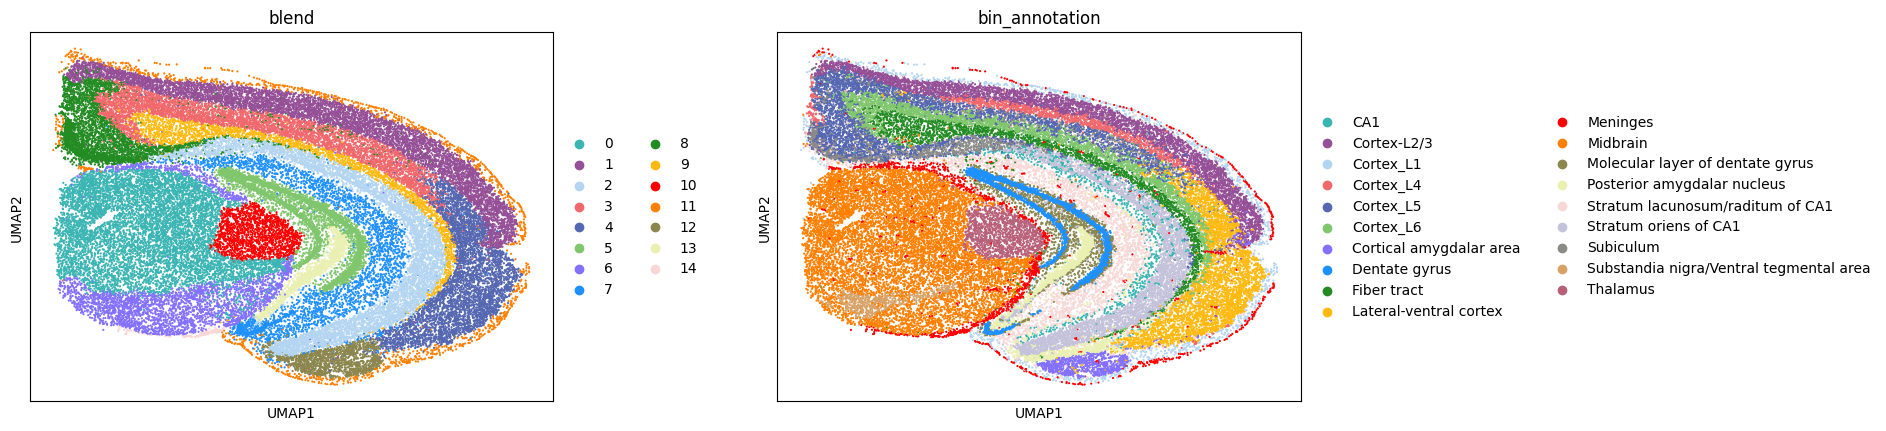

In [ ]:
adata.obsm['X_umap'] = adata.obsm['spatial']
sc.pl.umap(adata, color=['blend','bin_annotation'], palette=custom_colors, legend_loc='right margin', size=10, wspace = 0.3)